In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
ads_data = pd.read_csv('D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\Часть 1\\Задания\\Ноутбуки и датасеты\\Ноутбуки и датасеты\\lesson_5_ads_data.csv.zip',compression='zip')

In [4]:
# Получить статистику по дням.
# Просто посчитать число уникальных объявлений и уникальных кампаний.
# Разобраться, почему случился такой скачок 2019-04-05? Каких событий стало больше? У всех объявлений или только у некоторых?

# Найти топ 10 объявлений по CTR за все время. CTR — это отношение всех просмотров объявления к кликам. Например, если у объявления было 100 показов и 2 клика, CTR = 0.02. Различается ли средний и медианный CTR объявлений в наших данных?

# Похоже, в наших логах есть баг, объявления приходят с кликами, но без показов!
# Сколько таких объявлений, есть ли какие-то закономерности? Эта проблема наблюдается на всех платформах?

# Есть ли различия в CTR у объявлений с видео и без? А чему равняется 95 процентиль CTR по всем объявлениям за 2019-04-04?

# Для финансового отчета нужно рассчитать наш заработок по дням. В какой день мы заработали больше всего? В какой меньше? Мы списываем с клиентов деньги, если произошел клик по CPC объявлению, и мы списываем деньги за каждый показ CPM объявления, если у CPM объявления цена - 200 рублей, то за один показ мы зарабатываем 200 / 1000.
# Какая платформа самая популярная для размещения рекламных объявлений? Сколько процентов показов приходится на каждую из платформ (колонка platform)?

# А есть ли такие объявления, по которым сначала произошел клик, а только потом показ?

In [5]:
ads_data.head()

,ad_id,time,event,date,ad_cost_type,has_video,client_union_id,campaign_union_id,platform,ad_cost,target_audience_count,user_id
0,23456,1554076848,view,2019-04-01,CPM,0,5681,23456,android,190.0,125560,793
1,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,1041
2,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,41
3,42987,1554135866,view,2019-04-01,CPM,0,28541,42985,ios,199.1,80160,898
4,23456,1554135866,view,2019-04-01,CPM,0,5681,23456,web,190.0,125560,29


In [6]:
ads_data['full_date'] = pd.to_datetime(ads_data.time, unit='s')

In [7]:
ads_data['date'] = pd.to_datetime(ads_data.date)

In [8]:
ads_data.dtypes

ad_id                             int64
time                              int64
event                            object
date                     datetime64[ns]
ad_cost_type                     object
has_video                         int64
client_union_id                   int64
campaign_union_id                 int64
platform                         object
ad_cost                         float64
target_audience_count             int64
user_id                           int64
full_date                datetime64[ns]
dtype: object

<Axes: xlabel='date'>

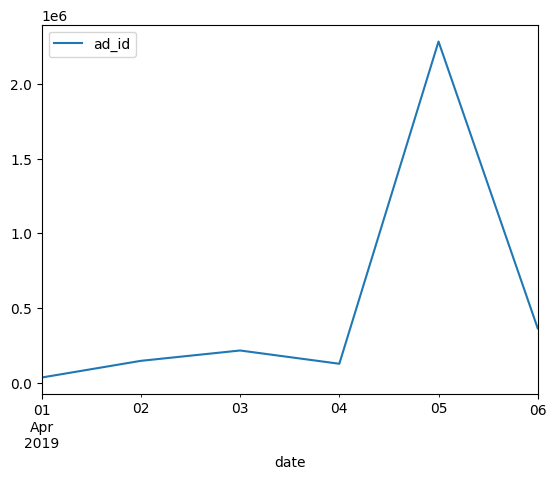

In [9]:
ads_data.groupby('date')\
    .agg({'ad_id': 'count'}).plot()

In [10]:
ads_data.groupby(['date', 'event'], as_index=False)\
    .agg({'ad_id': 'count'})\
    .pivot(index='date', columns='event', values='ad_id').reset_index()

event,date,click,view
0,2019-04-01,735,34832
1,2019-04-02,1518,145811
2,2019-04-03,1678,214851
3,2019-04-04,1517,126182
4,2019-04-05,501595,1783288
5,2019-04-06,80420,284287


In [11]:
ads_data.head()

,ad_id,time,event,date,ad_cost_type,has_video,client_union_id,campaign_union_id,platform,ad_cost,target_audience_count,user_id,full_date
0,23456,1554076848,view,2019-04-01,CPM,0,5681,23456,android,190.0,125560,793,2019-04-01 00:00:48
1,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,1041,2019-04-01 16:24:26
2,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,41,2019-04-01 16:24:26
3,42987,1554135866,view,2019-04-01,CPM,0,28541,42985,ios,199.1,80160,898,2019-04-01 16:24:26
4,23456,1554135866,view,2019-04-01,CPM,0,5681,23456,web,190.0,125560,29,2019-04-01 16:24:26


In [12]:
## Просто посчитать число уникальных объявлений и уникальных кампаний.


In [13]:
ads_data[['ad_id', 'campaign_union_id']].nunique()

ad_id                355
campaign_union_id    349
dtype: int64

In [14]:
# Найти топ 10 объявлений по CTR за все время. CTR — это отношение всех просмотров объявления к кликам. Например, если у объявления было 100 показов и 2 клика, CTR = 0.02. Различается ли средний и медианный CTR объявлений в наших данных?


In [15]:
ads_data.dtypes

ad_id                             int64
time                              int64
event                            object
date                     datetime64[ns]
ad_cost_type                     object
has_video                         int64
client_union_id                   int64
campaign_union_id                 int64
platform                         object
ad_cost                         float64
target_audience_count             int64
user_id                           int64
full_date                datetime64[ns]
dtype: object

In [16]:
ads_data_by_ad = ads_data.groupby(['ad_id', 'event'], as_index=False)\
    .agg({'time': 'count'})\
    .pivot(index='ad_id', columns='event', values='time').reset_index()
ads_data_by_ad

event,ad_id,click,view
0,3,9.0,490.0
1,2132,1.0,95.0
2,2276,2.0,1454.0
3,2475,NaN,132.0
4,2643,3.0,286.0
...,...,...,...
350,121941,1.0,640.0
351,121943,15.0,1722.0
352,122042,1.0,155.0
353,122063,1.0,260.0


In [17]:
ads_data_by_ad = ads_data.assign(ctr = ads_data.click / ads_data.view,
                           ctr_per = 100* ads_data.click / ads_data.view,)

# error

AttributeError: 'DataFrame' object has no attribute 'click'

In [ ]:
ads_data_by_ad.sort_values('ctr', ascending=False)

In [ ]:
ads_data_by_ad.ctr.mean()

In [ ]:
ads_data_by_ad.ctr.median()

In [ ]:
sns.displot(ads_data_by_ad.ctr, kde=False)

In [ ]:
# Похоже, в наших логах есть баг, объявления приходят с кликами, но без показов!
# Сколько таких объявлений, есть ли какие-то закономерности? Эта проблема наблюдается на всех платформах?

In [ ]:
ads_data_by_ad = ads_data.fillna(0)
ads_data

In [ ]:
ad_ids_bug = ads_data.query('click == 0').ad_id

In [ ]:
ads_data[ads_data.ad_id.isin(ad_ids_bug)]\
    .groupby('platform', as_index=False)\
    .agg({'ad_id': 'count'})\
    .sort_values('ad_id', ascending=False)

In [ ]:
# Есть ли различия в CTR у объявлений с видео и без? А чему равняется 95 процентиль CTR по всем объявлениям за 2019-04-04?


In [ ]:
ads_data.head()

In [18]:
df_2019_04_04 = ads_data[ads_data.date == '2019-04-04'].groupby(['ad_id', 'event'], as_index=False)\
    .agg({'time': 'count'})\
    .pivot(index='ad_id', columns='event', values='time').reset_index()\
    .fillna(0)
df_2019_04_04

event,ad_id,click,view
0,9071,3.0,352.0
1,9776,37.0,1115.0
2,10601,3.0,848.0
3,11887,151.0,8720.0
4,12137,1.0,170.0
...,...,...,...
145,120790,0.0,19.0
146,121779,68.0,1116.0
147,121790,7.0,701.0
148,121941,0.0,95.0


In [ ]:
df_2019_04_04['ctr'] = df_2019_04_04.click / df_2019_04_04.view
df_2019_04_04[df_2019_04_04.click > 0].ctr.quantile(q=0.95)

In [ ]:
# Есть ли различия в CTR у объявлений с видео и без?
ads_data.head()

In [ ]:
df_video = ads_data.groupby(['ad_id', 'event', 'has_video'], as_index=False)\
    .agg({'time': 'count'})\
    .pivot(index='ad_id', columns=['event', 'has_video'], values='time').reset_index()\
    .fillna(0)

In [ ]:
df_video

In [ ]:
#Для финансового отчета нужно рассчитать наш заработок по дням. В какой день мы заработали больше всего? В какой меньше? Мы списываем с клиентов деньги, если произошел клик по CPC объявлению, и мы списываем деньги за каждый показ CPM объявления, если у CPM объявления цена - 200 рублей, то за один показ мы зарабатываем 200 / 1000.
# Какая платформа самая популярная для размещения рекламных объявлений? Сколько процентов показов приходится на каждую из платформ (колонка platform)?


In [ ]:
ads_data[(ads_data.ad_cost_type == 'CPC') & (ads_data.event == 'click')].ad_cost.sum()

In [ ]:
ads_data[(ads_data.ad_cost_type == 'CPM') & (ads_data.event == 'view')].ad_cost.sum() / 1000

In [ ]:
ads_data.groupby(['ad_id', 'event'], as_index=False)\
    .agg({'time' : 'min'})\
    .pivot(index='ad_id', columns='event', values='time').reset_index()\
    .query('click < view')